In [1]:
from nuscenes.nuscenes import NuScenes
import os
print(os.getcwd())
nusc = NuScenes(version='v1.0-test', dataroot='../output', verbose=True)

nusc.list_scenes()
my_scene = nusc.scene[0]

/workspaces/edgar2nuscenes/utils
Loading NuScenes tables for version v1.0-test...
Loading nuScenes-lidarseg...
32 category,
0 attribute,
0 visibility,
1202 instance,
3 sensor,
3 calibrated_sensor,
442 ego_pose,
1 log,
1 scene,
45 sample,
1149 sample_data,
1202 sample_annotation,
1 map,
0 lidarseg,
Done loading in 0.009 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
EDGAR_BAG, Edgar test data [70-01-01 00:28:46]    0s, Munich, #anns:1170


In [2]:
first_sample_token = my_scene['first_sample_token']
my_sample = nusc.get('sample', first_sample_token)
my_sample

{'prev': '',
 'token': 'bc769c39feb1b2cc5a103b0013561c87',
 'next': '4799e9e66a54ff42ab93b28bb8de411d',
 'timestamp': 1726137641.545991,
 'scene_token': 'ca48fc24411b67c1fe6c3dfe21d559a3',
 'data': {'CAM_rearcenter': '28ccc59c393833a5088b682c888ad728',
  'CAM_frontcenter': 'ab598c755ed772c4ac4a49e5fb23e73c',
  'LIDAR_TOP': 'e009a945444e4069bdd7ce9eece7fee7'},
 'anns': ['60e9f457370f274e470f6ff96be230e3',
  '1369ba5fd3740a34f66baf9e537669a3',
  '6a78b3bfd9cdeb172c0e47f30372cd5c',
  '825f1c4c548ed79160c4f91fc87bb597',
  'e68be941c4fb569adfb87e5ff1e41d4a',
  '892dccd628107d097c8d2f341f585666',
  'ac69715b15ad3d58c1d283a00aa39f35',
  'b007f66ad9fa043484ddd53ff616d2e6',
  '6fda005cd66b3248add4d96866b2a998',
  'bcbee8083c3d757a4915ea309952ccdf',
  '12f3732212ba61388984d867d06caccf',
  '521596d1bf22b259cf0f4ee1b9e57261',
  '87503ceac3ee8456cd8fb6541feb7f65',
  'bf486993ef8fc202ba87d7ecfa65b499',
  '06735f583752248366a5049db2754676',
  '84c477875eef1435f257c8992a7361f2',
  'eb895508bd70e455b47

In [3]:


nusc.list_sample(my_sample['token'])



Sample: bc769c39feb1b2cc5a103b0013561c87

sample_data_token: 28ccc59c393833a5088b682c888ad728, mod: camera, channel: CAM_rearcenter
sample_data_token: ab598c755ed772c4ac4a49e5fb23e73c, mod: camera, channel: CAM_frontcenter
sample_data_token: e009a945444e4069bdd7ce9eece7fee7, mod: lidar, channel: LIDAR_TOP

sample_annotation_token: 60e9f457370f274e470f6ff96be230e3, category: vehicle.car
sample_annotation_token: 1369ba5fd3740a34f66baf9e537669a3, category: vehicle.car
sample_annotation_token: 6a78b3bfd9cdeb172c0e47f30372cd5c, category: vehicle.car
sample_annotation_token: 825f1c4c548ed79160c4f91fc87bb597, category: vehicle.car
sample_annotation_token: e68be941c4fb569adfb87e5ff1e41d4a, category: vehicle.car
sample_annotation_token: 892dccd628107d097c8d2f341f585666, category: vehicle.car
sample_annotation_token: ac69715b15ad3d58c1d283a00aa39f35, category: vehicle.car
sample_annotation_token: b007f66ad9fa043484ddd53ff616d2e6, category: vehicle.car
sample_annotation_token: 6fda005cd66b3248add

In [4]:


my_sample['data']



{'CAM_rearcenter': '28ccc59c393833a5088b682c888ad728',
 'CAM_frontcenter': 'ab598c755ed772c4ac4a49e5fb23e73c',
 'LIDAR_TOP': 'e009a945444e4069bdd7ce9eece7fee7'}

In [5]:


sensor = 'LIDAR_TOP'
lidar_data = nusc.get('sample_data', my_sample['data'][sensor])
lidar_data



{'timestamp': 1726137641.4998858,
 'fileformat': 'pcd.bin',
 'filename': 'samples/LIDAR_TOP/rosbag__LIDAR_TOP__1726137641499885824.pcd.bin',
 'height': 0,
 'width': 0,
 'calibrated_sensor_token': 'e4a821bd63f4fd854745cb760a61a102',
 'token': 'e009a945444e4069bdd7ce9eece7fee7',
 'ego_pose_token': '7c511b53b6caef26dfc28540f531ca00',
 'sample_token': 'bc769c39feb1b2cc5a103b0013561c87',
 'next': 'ab598c755ed772c4ac4a49e5fb23e73c',
 'prev': '',
 'is_key_frame': True,
 'sensor_modality': 'lidar',
 'channel': 'LIDAR_TOP'}

In [6]:
my_annotation_token = my_sample['anns'][0]
my_annotation_metadata =  nusc.get('sample_annotation', my_annotation_token)
my_annotation_metadata

{'token': '60e9f457370f274e470f6ff96be230e3',
 'sample_token': 'bc769c39feb1b2cc5a103b0013561c87',
 'instance_token': 'e20e5363702aff5007ff05d991f6dcca',
 'visibility_token': '',
 'attribute_tokens': [],
 'translation': [18.688060760498047, 23.863727569580078, -0.4395700693130493],
 'size': [1.8557809591293335, 4.195906162261963, 1.5408453941345215],
 'rotation': [0.701011690685197, 0.0, 0.0, -0.7131497805669449],
 'num_lidar_pts': 10,
 'num_radar_pts': 10,
 'prev': '',
 'next': '',
 'category_name': 'vehicle.car'}

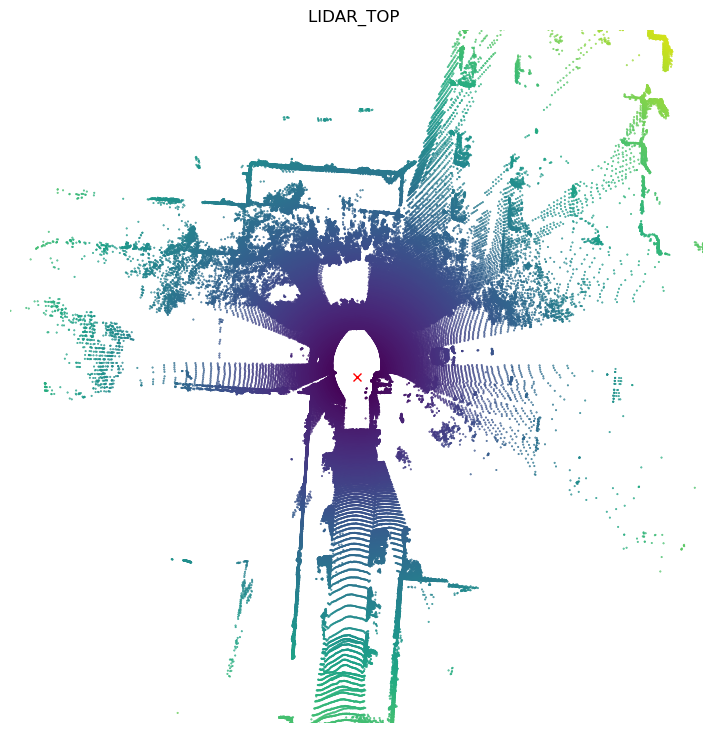

In [10]:


nusc.render_sample_data(lidar_data['token'], underlay_map=False,with_anns=True, box_vis_level=2, use_flat_vehicle_coordinates=False)

